In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('../data/PASS.csv')
data['File Name'] = data['File Name'].str.split('\\').str[-1]
data['File Name'] = data['File Name'].str.split('.').str[0]
data.head()

,File Name,_Water1_b1024,_Water1_e1024,_Water1_b1000,_Water1_e1000,_Water1_be950,_Water1_be856,_Water1_median,_Water1_sd,_Water1_mean,...,zCF75,zCF50,zCF20,zCF10,zCF5,zNyquist Frequency,CNR,SNR,CNR-v2,SNR-v2
0,1024_DFOV_200,0,0,0,0,0,0,-4,60.7011,-4.15662,...,2.936,5.130,9.755,12.049,13.923,25.0,1.27382,12.3072,0.571577,5.52237
1,1024_DFOV_250,0,0,0,0,0,0,-4,60.6918,-4.18150,...,2.934,5.125,9.750,12.060,13.928,25.0,1.27634,12.2849,2.172270,20.90830
2,1024_DFOV_300,0,0,0,0,0,0,-4,60.6905,-4.19127,...,2.937,5.120,9.717,12.050,13.921,25.0,1.27564,12.2812,2.234280,21.51040
3,1024_DFOV_350,0,0,0,0,0,0,-4,60.7192,-4.08833,...,2.937,5.124,9.711,12.034,13.890,25.0,1.27627,12.2670,2.307180,22.17570
4,1024_DFOV_400,0,0,0,0,0,0,-4,60.8053,-4.27941,...,2.933,5.122,9.684,12.027,13.885,25.0,1.27329,12.2858,2.371700,22.88420


In [3]:
def parse_name(name):
    parts = name.split('_')

    matrix = int(parts[0])
    dfov = int(parts[2])
    ir = "IR3" if "IR3" in parts else "FBP"
    resampled = 1 if "resampled" in parts else 0

    return pd.Series([matrix, dfov, ir, resampled])

data[['matrix','dfov','ir','resampled']] = data['File Name'].apply(parse_name)

In [4]:
def snr(mean, std):
    return np.abs(mean) / std

In [5]:
data['water_snr'] = snr(data['_Water1_mean'], data['_Water1_sd'])
data['abdominal_snr'] = snr(data['_Air_mean'], data['_Air_sd'])
data['tracheal_snr'] = snr(data['trachea_mean'], data['trachea_sd'])
data['outside_snr'] = snr(data['_OutsideAir_mean'], data['_OutsideAir_sd'])
data['nist4_snr'] = snr(data['_NIST4_mean'], data['_NIST4_sd'])
data['nist8_snr'] = snr(data['_NIST8_mean'], data['_NIST8_sd'])
data['nist12_snr'] = snr(data['_NIST12_mean'], data['_NIST12_sd'])
data['nist14_snr'] = snr(data['_NIST14_mean'], data['_NIST14_sd'])
data['nist20_snr'] = snr(data['_NIST20_mean'], data['_NIST20_sd'])

In [14]:
def plot_dfov_groups(data, val):

    groups = list(data.groupby(["matrix", "ir"]))
    colors = {512: "red", 1024: "blue"}

    n = len(groups)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(10*ncols/2, 4*nrows))
    fig.suptitle(val)
    axes = axes.flatten()

    for i, ((matrix, ir_type), df_sub) in enumerate(groups):

        ax = axes[i]

        sns.scatterplot(
            data=df_sub,
            x="dfov",
            y=val,
            style="resampled",
            markers={0: "o", 1: "s"},
            color=colors[matrix],
            s=100,
            ax=ax
        )

        for resampled_flag, df_r in df_sub.groupby("resampled"):

            if df_r["dfov"].nunique() > 1:

                x = df_r["dfov"].values
                y = df_r[val].values

                coeffs = np.polyfit(x, y, 2)
                poly = np.poly1d(coeffs)
                y_pred = poly(x)

                ss_res = np.sum((y - y_pred)**2)
                ss_tot = np.sum((y - np.mean(y))**2)
                r2 = 1 - ss_res / ss_tot

                sns.regplot(
                    data=df_r,
                    x="dfov",
                    y=val,
                    scatter=False,
                    order=2,
                    ci=None,
                    color=colors[matrix],
                    line_kws={
                        "linestyle": "-" if resampled_flag else "--",
                        "linewidth": 2.5
                    },
                    label=f"{'resampled' if resampled_flag else 'native'} (R²={r2:.3f})",
                    ax=ax
                )

        ax.set_title(f"{matrix} | {ir_type}")
        ax.set_xlabel("DFOV")
        ax.set_ylabel(val)
        ax.legend()

    # remove unused axes
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

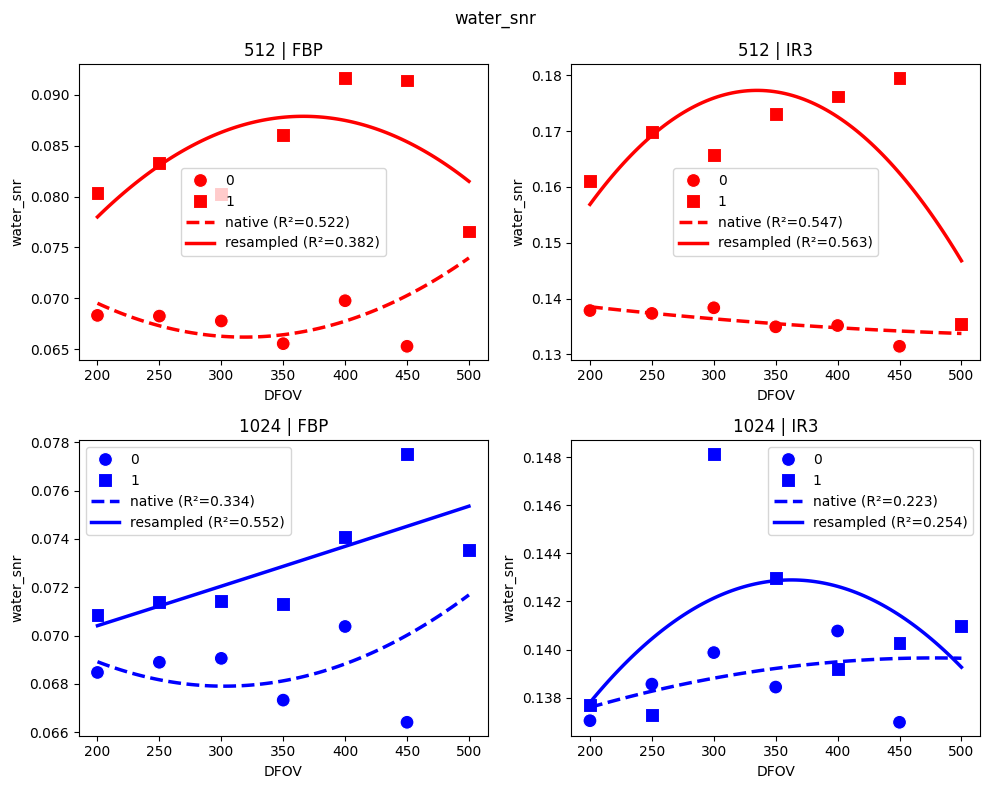

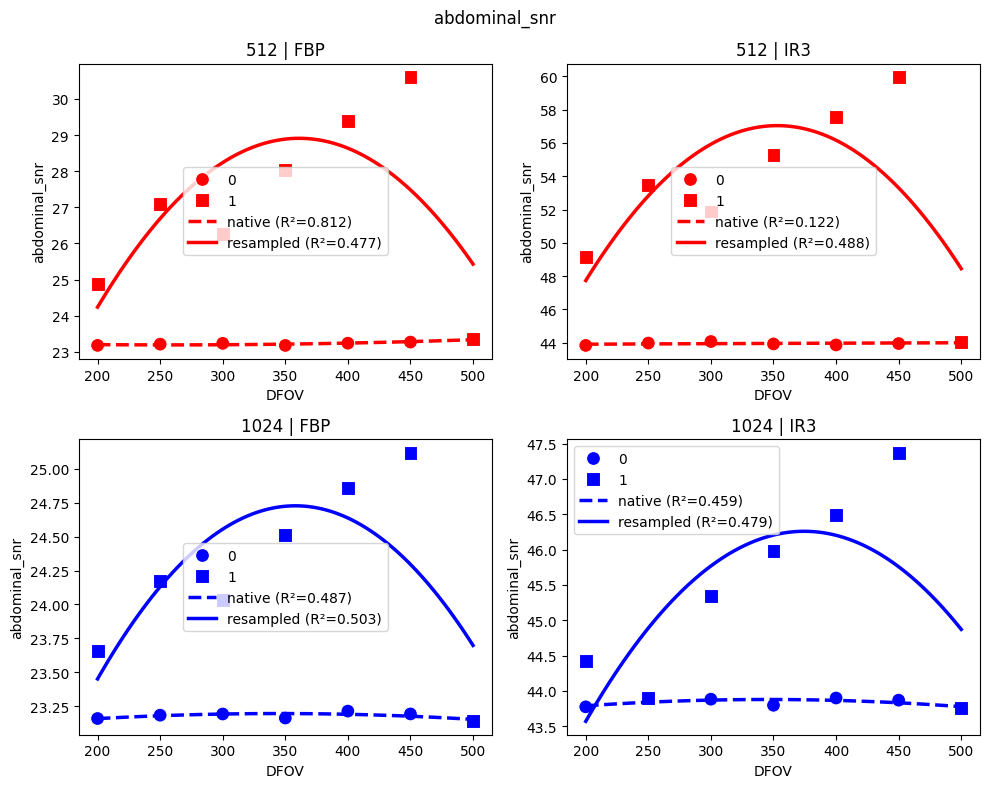

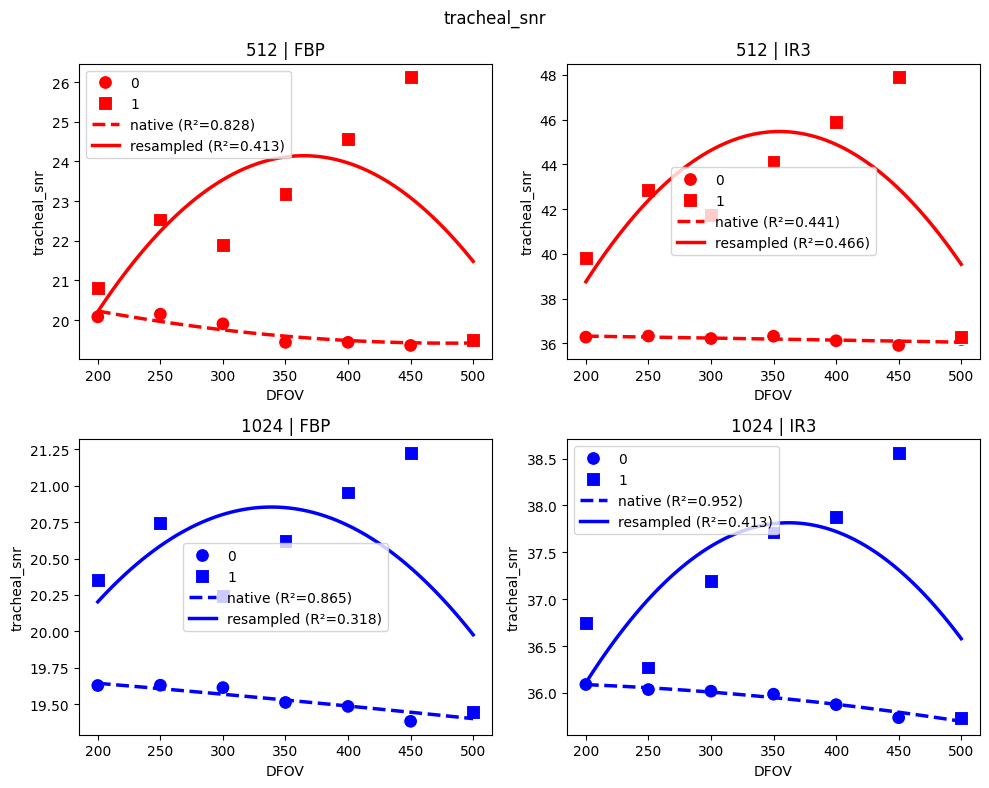

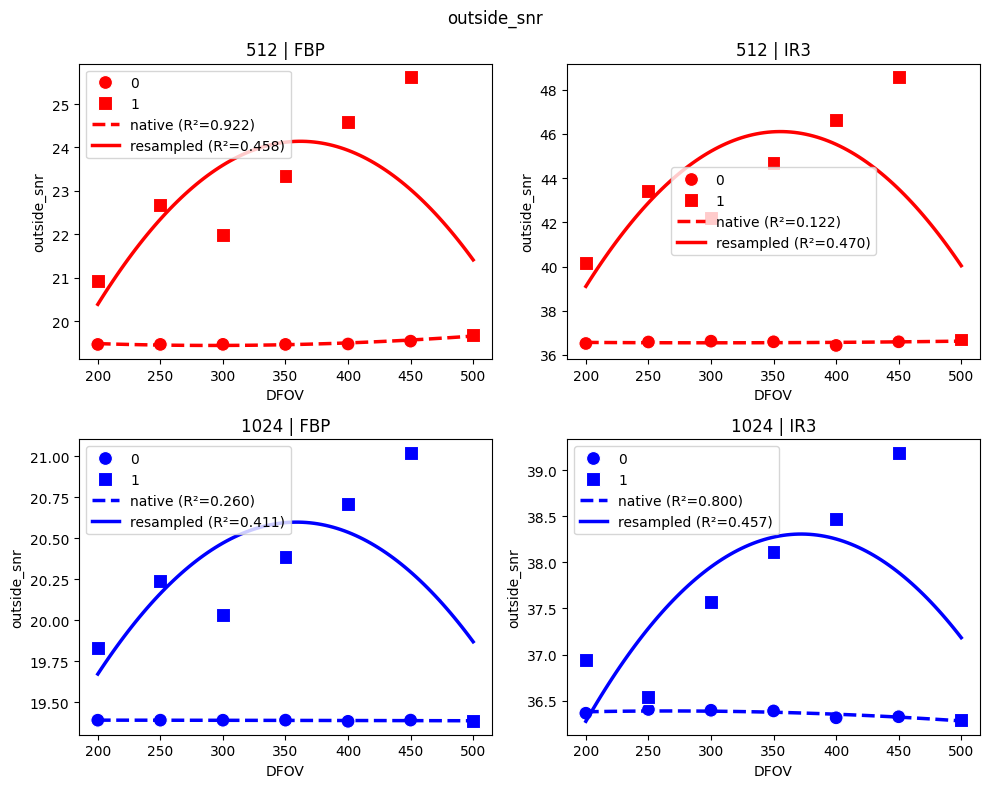

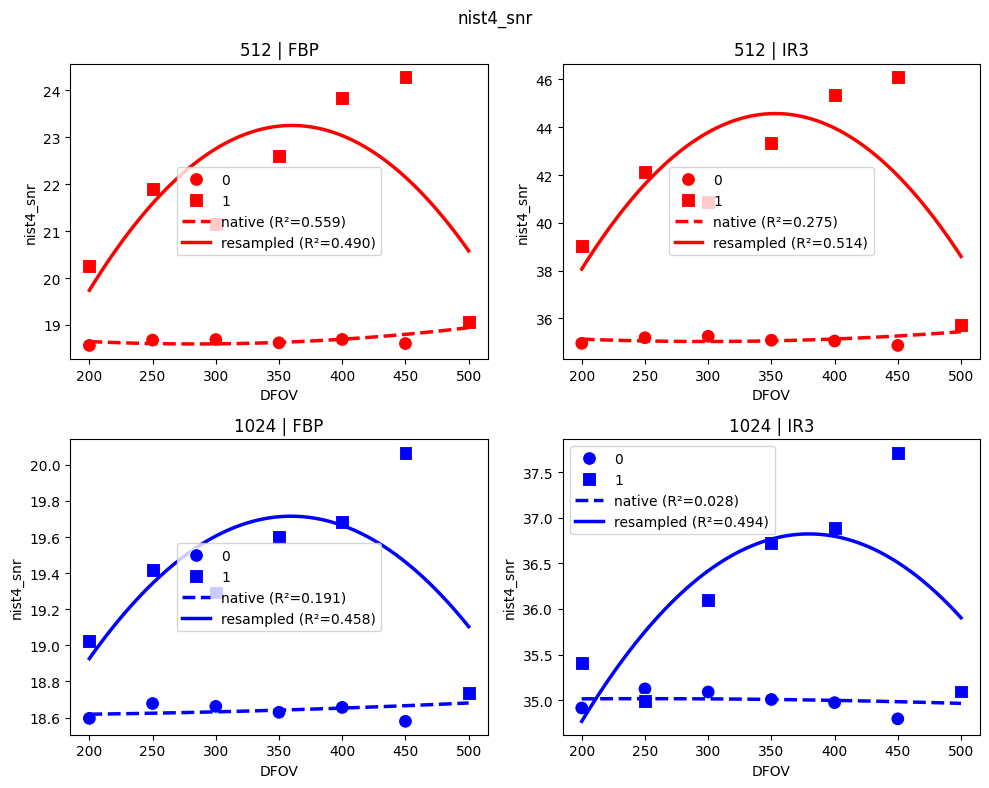

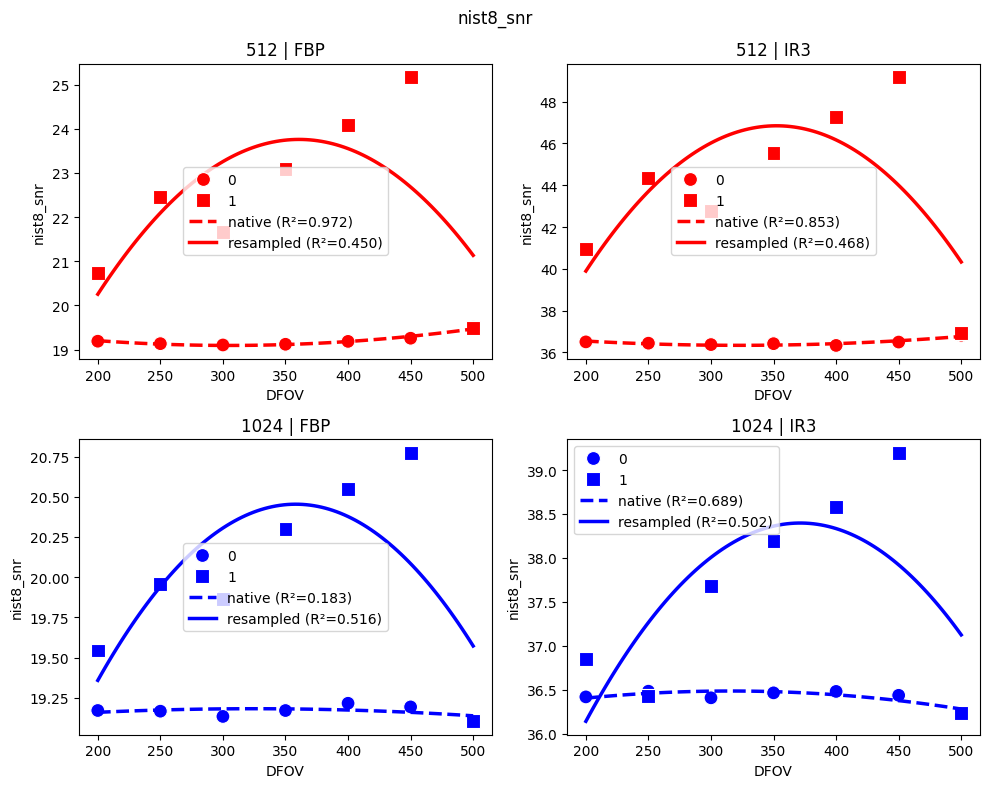

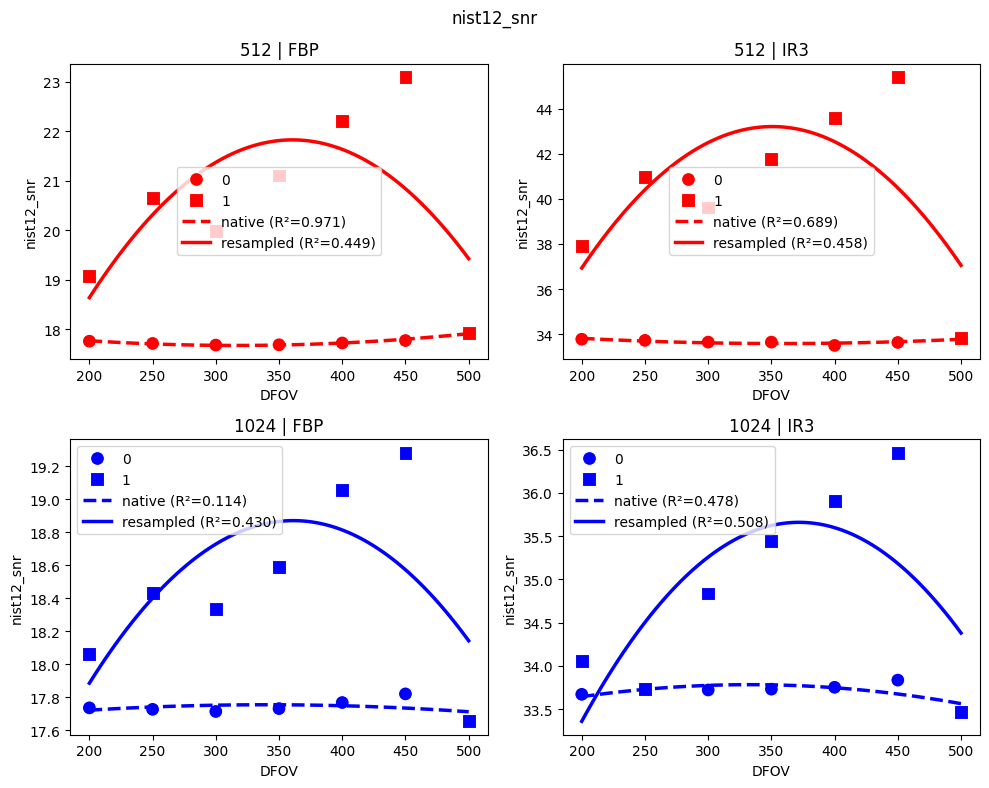

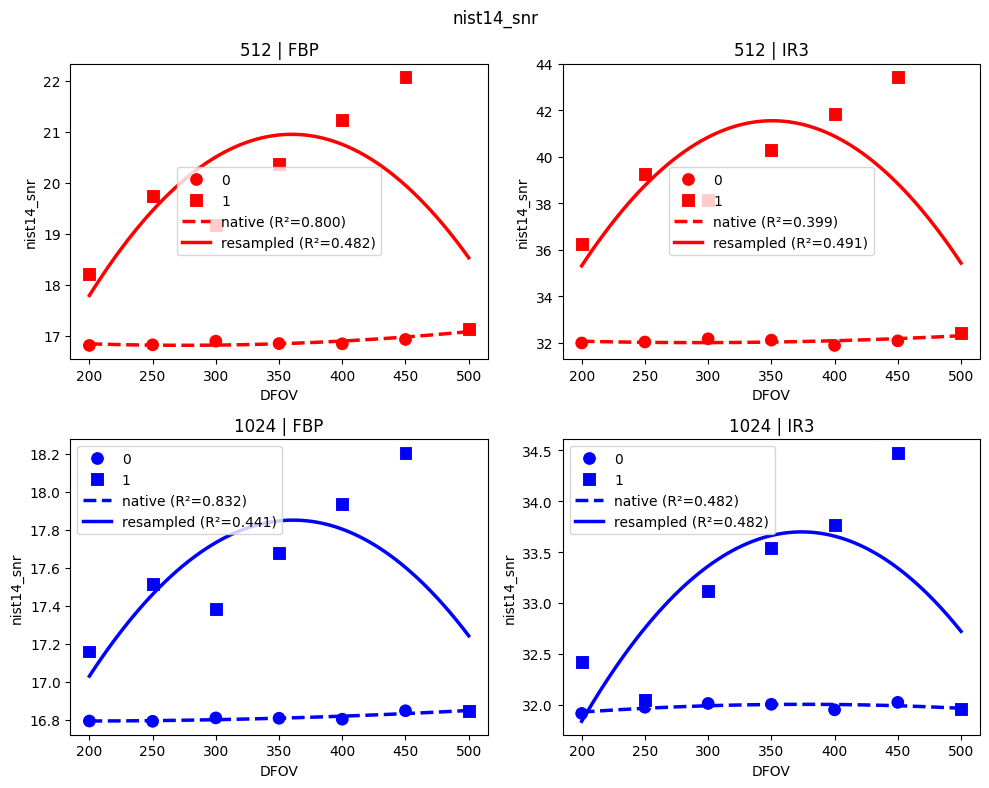

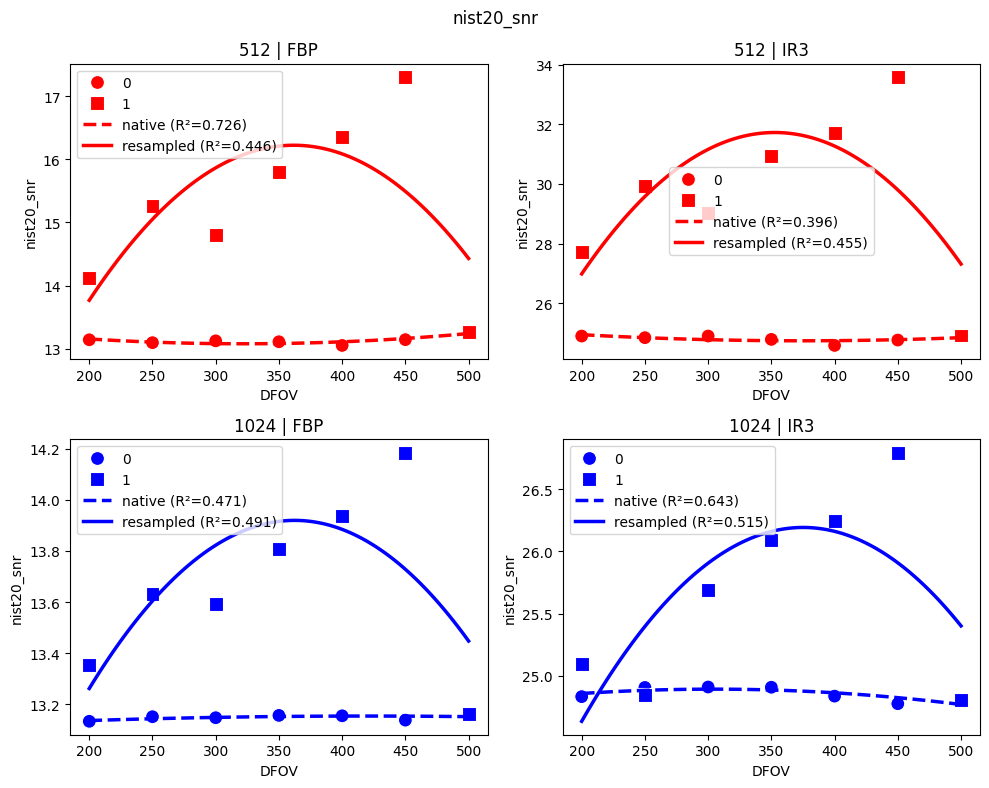

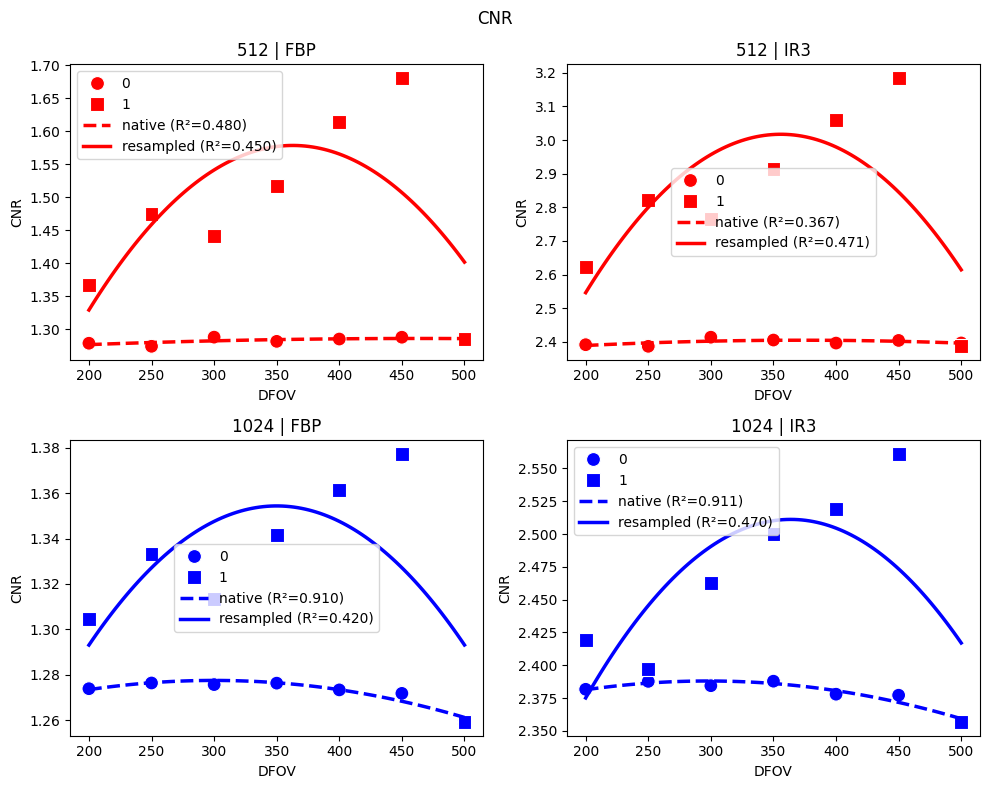

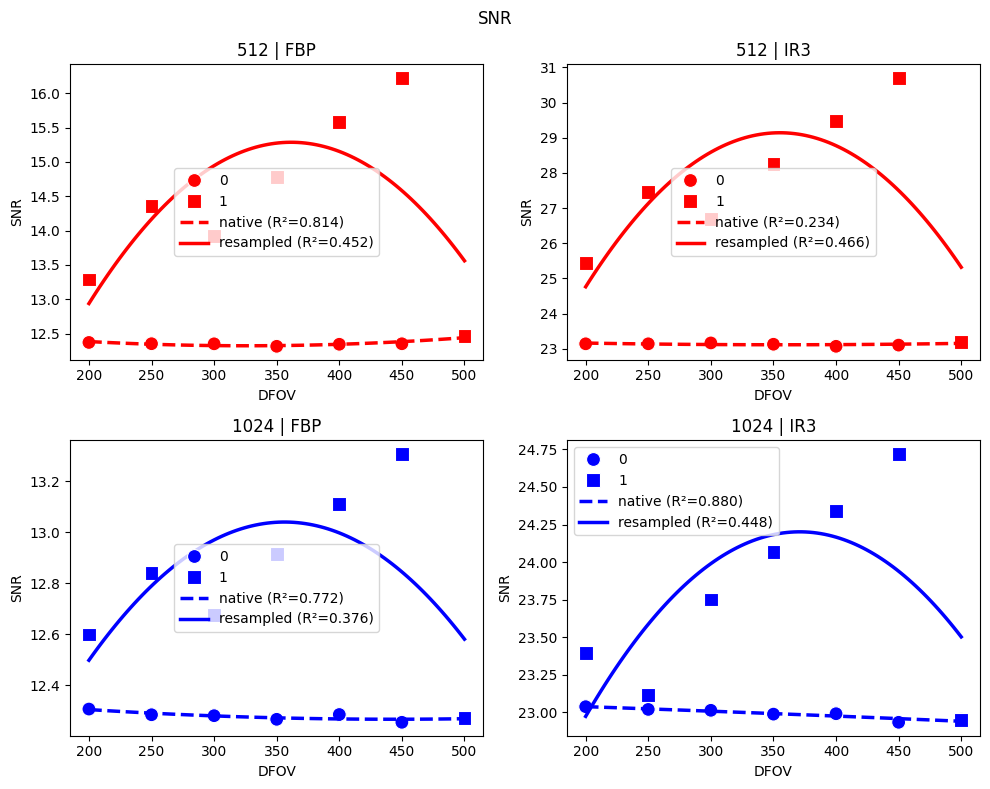

In [19]:
metrics = [
    "water_snr",
    "abdominal_snr",
    "tracheal_snr",
    "outside_snr",
    "nist4_snr",
    "nist8_snr",
    "nist12_snr",
    "nist14_snr",
    "nist20_snr",
    "CNR",
    "SNR"
]

for m in metrics:
    plot_dfov_groups(data, m)